In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import sqlite3
import pandas as pd
import os

In [119]:
# Global style settings
plt.rcParams.update({
    'figure.figsize': (10, 8),   # Size of all plots
    'axes.grid': True,           # Enable grid
    'grid.alpha': 0.3,           # Grid transparency
    'grid.linestyle': '--',      # Grid style
    'font.size': 12,             # Base font size
    'axes.titlesize': 16,        # Title size
    'axes.labelsize': 14,        # Axis labels
})

In [2]:
DB_PATH = db_path = r"H:\ua-aid-intelligence-hub\data\master\master.db"

def get_donations_in_eur():
    """
    Extracts all donations, converts UAH to EUR, retains the exchange rate,
    and drops the original UAH amount. Preserves all other metadata.
    """
    query = """
    SELECT
        d.id,
        d.date,
        d.foundation_name,
        d.category,
        ROUND(d.amount / er.rate_uah, 2) AS amount_eur,
        er.rate_uah AS eur_exchange_rate,
        d.currency AS original_currency,
        d.comment,
        d.source AS donation_source
    FROM donations d
    LEFT JOIN exchange_rates er
        ON d.date = er.date AND er.currency = 'EUR'
    ORDER BY d.date DESC;
    """

    try:
        with sqlite3.connect(DB_PATH) as conn:
            df_donations = pd.read_sql_query(query, conn)
            # Convert date strings to datetime objects for time-series analysis
            df_donations['date'] = pd.to_datetime(df_donations['date'])
            return df_donations
    except Exception as e:
        print(f"Database extraction failed: {e}")
        return pd.DataFrame()

def get_daily_aggregated_news():
    """
    Extracts news data and aggregates multiple headlines and sources
    per day into single strings to prevent row duplication upon merging.
    """
    query = """
    SELECT
        date,
        GROUP_CONCAT(source, ' | ') AS daily_sources,
        GROUP_CONCAT(headers, ' | ') AS daily_headers
    FROM news
    GROUP BY date
    ORDER BY date DESC;
    """

    try:
        with sqlite3.connect(DB_PATH) as conn:
            df_news = pd.read_sql_query(query, conn)
            # Convert date strings to datetime objects to ensure clean merging later
            df_news['date'] = pd.to_datetime(df_news['date'])
            return df_news
    except Exception as e:
        print(f"Database extraction failed: {e}")
        return pd.DataFrame()

# 1. Load donations dataset
df_donations = get_donations_in_eur()
print(f"Donations dataset loaded: {len(df_donations)} rows.")

# 2. Load aggregated news dataset
df_news = get_daily_aggregated_news()
print(f"News dataset loaded: {len(df_news)} rows.")

# Display settings for clear data visualization in Jupyter
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_colwidth = 80

Donations dataset loaded: 2067523 rows.
News dataset loaded: 407 rows.


In [77]:
df_donations.head()

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source
0,"9,658,284.00",2026-04-03,come_back_alive,general,19.82,50.46,UAH,UKR ***3871 (1000 UAH),Card payment
1,"9,658,285.00",2026-04-03,come_back_alive,general,19.82,50.46,UAH,UKR ***6287 (1000 UAH),Card payment
2,"9,658,286.00",2026-04-03,come_back_alive,general,86.71,50.46,USD,USA ***6318 (100 USD),Card payment
3,"9,658,287.00",2026-04-03,come_back_alive,general,3.96,50.46,UAH,UKR ***2582 (200 UAH),Card payment
4,"9,658,288.00",2026-04-03,come_back_alive,general,2.48,50.46,UAH,UKR ***1686 (125 UAH),Card payment


In [78]:
df_news.head()

,date,daily_sources,daily_headers
0,2026-03-04,theguardian.com,['Ukraine war briefing: Merz tells Trump Ukraine must not give up more terri...
1,2026-03-03,kyivindependent.com | theguardian.com,"[""How will Trump's war against Iran impact Ukraine?"", 'What to do if you’re ..."
2,2026-03-02,kyivindependent.com | theguardian.com,['Any comparison of the US-Iran conflict to the Russia-Ukraine war is ignora...
3,2026-03-01,kyivindependent.com | theguardian.com,"[""'Ukrainians made it through,' Zelensky says on toughest winter of Russia's..."
4,2026-02-28,kyivindependent.com | theguardian.com,"[""Russia condemns US attack on its ally Iran as 'unprovoked act of aggressio..."


In [79]:
df = df_donations.copy()

The goal is to study "grassroots" donations by filtering for transactions under €10,000.

Since we have transaction-level data only for the 'Come Back Alive' (CBA) foundation, while United24 provides only daily aggregates (which would be automatically filtered out by this limit), I am focusing exclusively on CBA. By looking only at payments under €10k, I want to analyze the behavior of "ordinary" people rather than large organizations or funds.

In [80]:
df = df.query('foundation_name == "come_back_alive" and amount_eur <= 10000')

In [81]:
df.dtypes

id                          float64
date                 datetime64[ns]
foundation_name              object
category                     object
amount_eur                  float64
eur_exchange_rate           float64
original_currency            object
comment                      object
donation_source              object
dtype: object

In [82]:
dayly = df.groupby('date', as_index = False)\
        .agg({'amount_eur':'sum'})
dayly.head()

,date,amount_eur
0,2025-01-01,"130,061.34"
1,2025-01-02,"119,679.23"
2,2025-01-03,"124,264.38"
3,2025-01-04,"51,120.76"
4,2025-01-05,"49,416.61"


<Axes: xlabel='date', ylabel='amount_eur'>

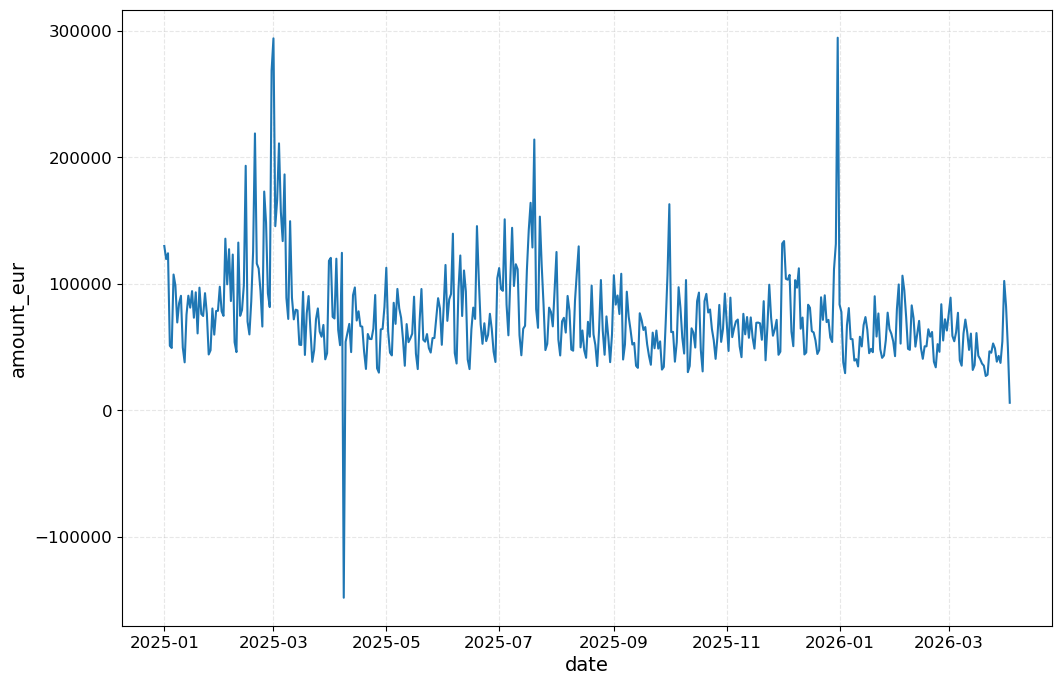

In [83]:
sns.lineplot(dayly, y = 'amount_eur', x = 'date')

Anomaly Detection: Negative Values
A quick look at the plot reveals a sharp drop into negative numbers. This is highly unusual behavior for donations. Let's dig deeper to investigate these negative records.

In [84]:
dayly[dayly.amount_eur < 0]

,date,amount_eur
97,2025-04-08,"-147,998.00"


<Axes: >

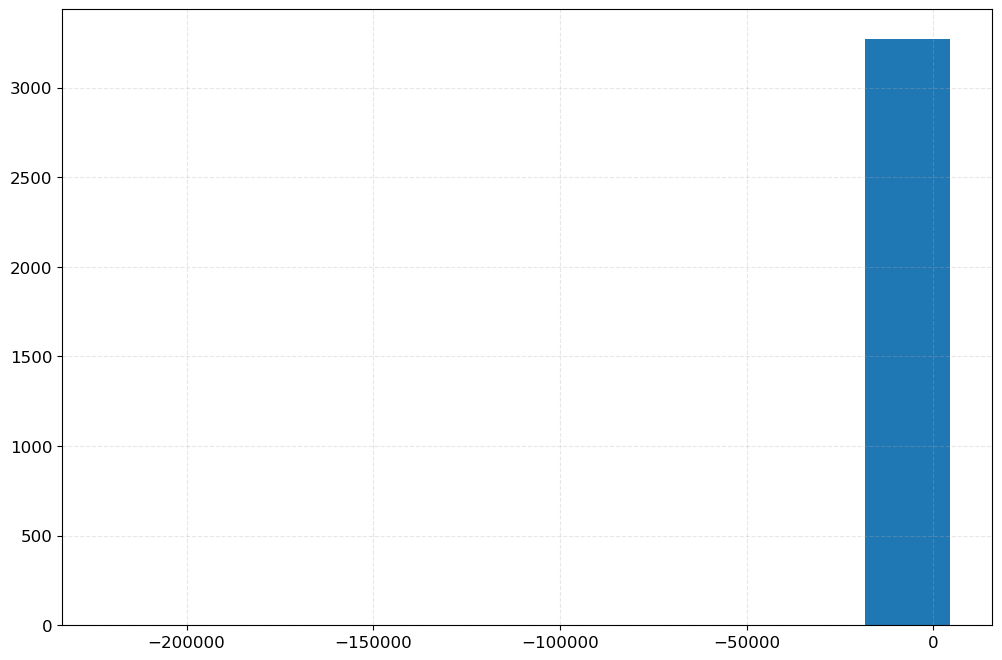

In [85]:
df[df.date == '2025-04-08'].amount_eur.hist()

In [86]:
df[(df['date'] == '2025-04-08') & (df['amount_eur'] < 0)]

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source
1524092,"5,346,274.00",2025-04-08,come_back_alive,general,"-221,959.82",45.05,UAH,"Перерахування коштів згідно Додаткової Угоди № 2 від 27.03.2025 р., без ПДВ ...",Повернення коштів
1524866,"5,226,638.00",2025-04-08,come_back_alive,general,-15.54,45.05,UAH,"Віталій Є. -- Благодійна пожертва на Фонд Повернись живим, STN15508792882736375",Monobank


Fortunately, there are only two records with negative donation amounts. This makes it easy to look into the raw data and find out exactly what caused the graph to anomalously drop below zero.

In [87]:
df.loc[1524092, 'comment']

'Перерахування коштів згідно Додаткової Угоди № 2 від 27.03.2025 р., без ПДВ - ПАТ УКРНАФТА'

Translation
"Transfer of funds according to Addendum No. 2 dated March 27, 2025, VAT-exempt - PJSC UKRNAFTA"

Conclusion: This is a corporate accounting correction (likely a refund) from a major oil company. It is a technical transaction, not a regular grassroots donation, and must be removed from our dataset.

In [88]:
df = df[df['amount_eur'] >= 0]

<Axes: xlabel='date', ylabel='amount_eur'>

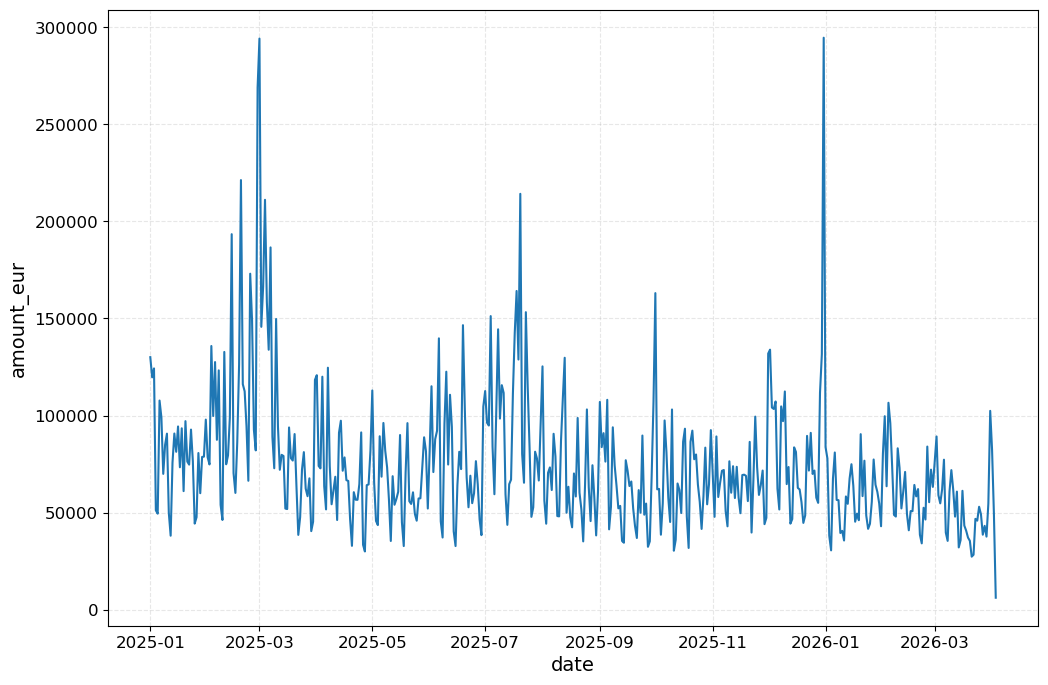

In [89]:
#lets's look at the gpaph now after I fixed it
dayly = df.groupby('date', as_index = False)\
        .agg({'amount_eur':'sum'})

sns.lineplot(dayly, y = 'amount_eur', x = 'date')

Okay, now everything is fine, we can start exploring public donations.

<Axes: xlabel='date', ylabel='amount_eur'>

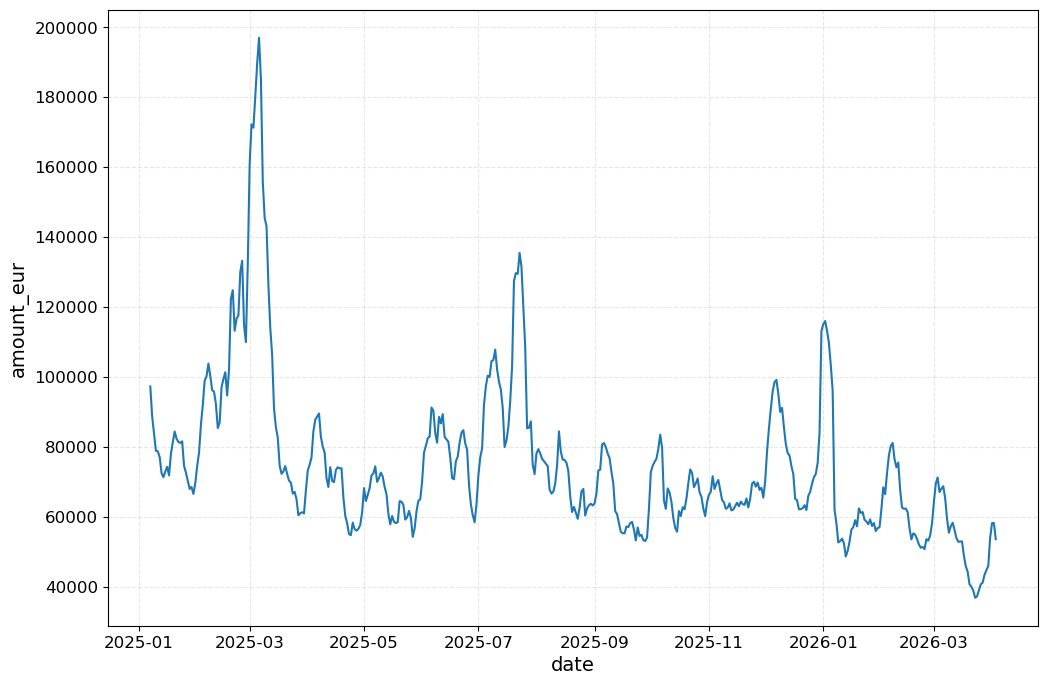

In [90]:
sns.lineplot(y = dayly.amount_eur.rolling(7).mean(), x = dayly.date)

Made the line smoother using rolling window 7 days. From the graph, it is clear that the trend is decreasing; let's verify this using linear regression.

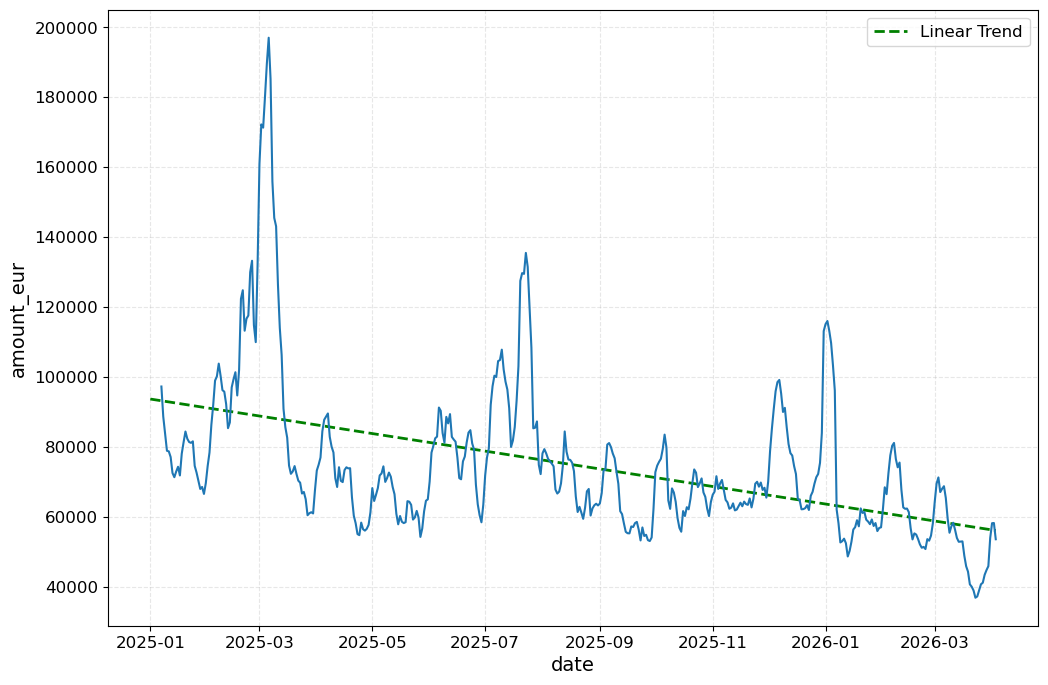

In [91]:
# 1. Convert datetime to numeric values for regression math
x_numeric = mdates.date2num(dayly['date'])
y_values = dayly['amount_eur']

# 2. Calculate linear regression 
coefficients = np.polyfit(x_numeric, y_values, 1)
trend_function = np.poly1d(coefficients)

plt.plot(dayly['date'], trend_function(x_numeric), color='green', linestyle='--', linewidth=2, label='Linear Trend')
sns.lineplot(y = dayly.amount_eur.rolling(7).mean(), x = dayly.date)
plt.legend()

In [92]:
dayly['weekday'] = dayly.date.dt.day_name()

In [93]:
dayly.head()

,date,amount_eur,weekday
0,2025-01-01,"130,061.34",Wednesday
1,2025-01-02,"119,683.82",Thursday
2,2025-01-03,"124,264.38",Friday
3,2025-01-04,"51,121.91",Saturday
4,2025-01-05,"49,418.91",Sunday


Let's see which days people donate most

<Axes: xlabel='weekday', ylabel='amount_eur'>

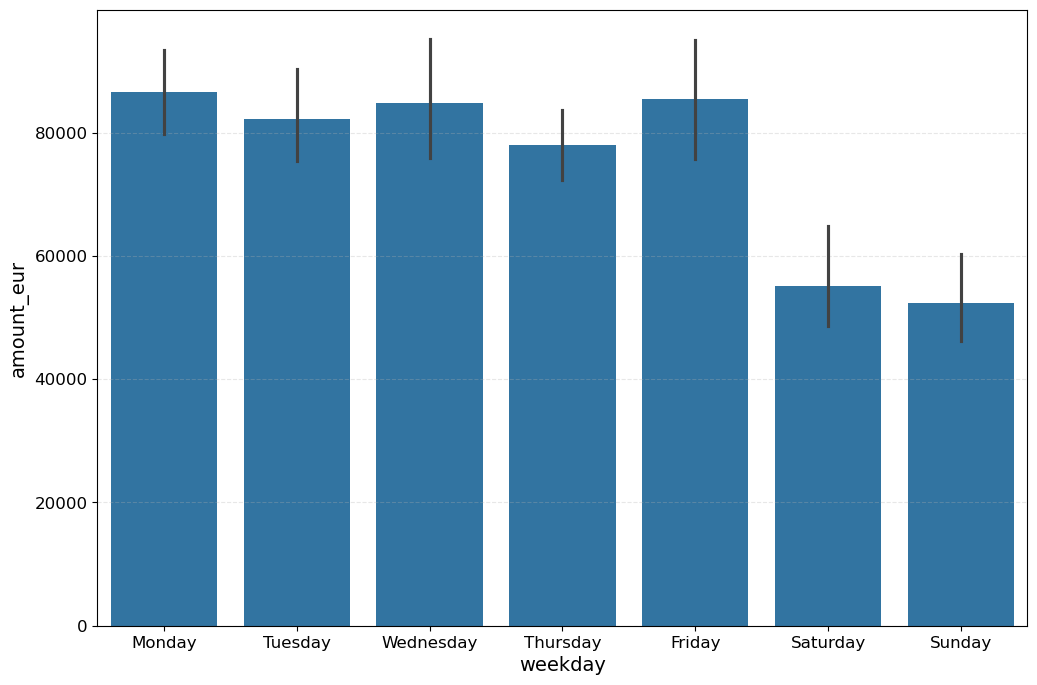

In [94]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(x = dayly.weekday, y = dayly.amount_eur, order = order)

<Axes: xlabel='weekday', ylabel='amount_eur'>

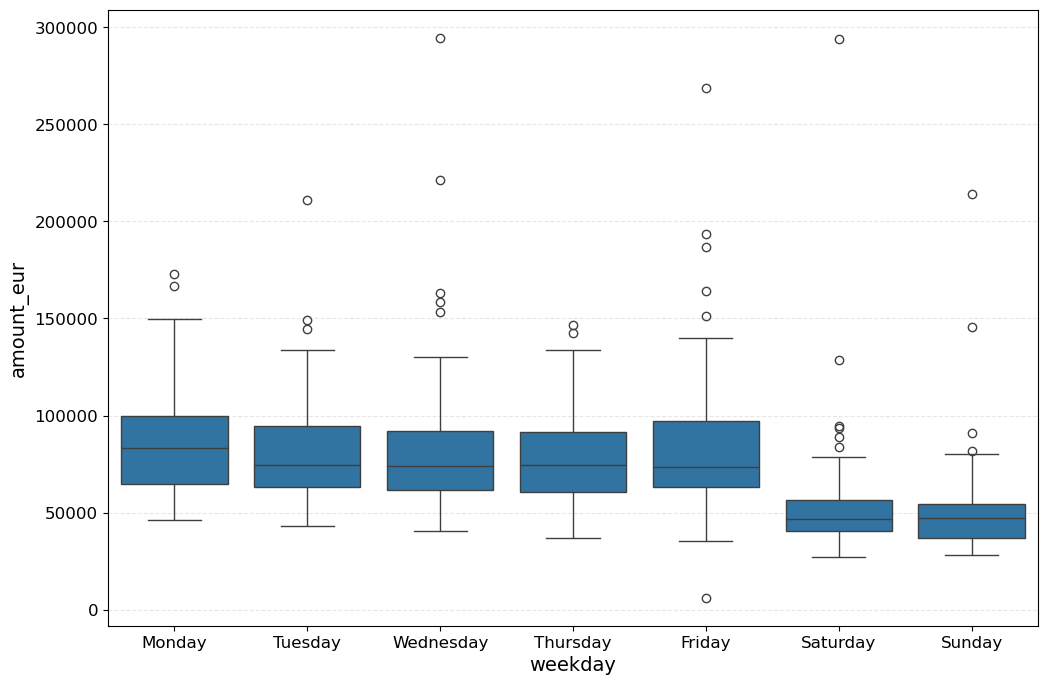

In [95]:
sns.boxplot(x = dayly.weekday, y = dayly.amount_eur, order = order)

We observe a fairly even and logical distribution across the days, with slightly lower values on weekends because many automated services do not operate then. The chart shows that Monday is one of the busiest days (as it includes automated transactions from the weekend). The boxplot also reveals a significant number of outliers, so let’s take a closer look at them.

In [96]:
dayly[dayly.amount_eur > 140000].shape

(21, 3)

In [97]:
dayly[(dayly.weekday.isin(['Saturday', 'Sunday'])) & (dayly.amount_eur > 70000)].shape

(17, 3)

In [98]:
#making two different datasets for working days and weekends for closer look
anomalies_work = dayly[dayly.amount_eur > 140000]
anomalies_week = dayly[(dayly.weekday.isin(['Saturday', 'Sunday'])) & (dayly.amount_eur > 70000)]

Fortunately for us (and unfortunately for the Ukrainian people), we do not have many days with such serious anomalies — only 38 — so we can take a closer look at them.

In [99]:
anomalies_week.head()

,date,amount_eur,weekday
17,2025-01-18,"93,407.18",Saturday
31,2025-02-01,"78,450.19",Saturday
32,2025-02-02,"74,794.37",Sunday
45,2025-02-15,"70,312.26",Saturday
52,2025-02-22,"94,483.60",Saturday


In [106]:
anomalies = pd.concat([anomalies_work, anomalies_week])\
            .sort_values('date').reset_index(drop = True)

In [108]:
anomalies.head(10)

,date,amount_eur,weekday
0,2025-01-18,"93,407.18",Saturday
1,2025-02-01,"78,450.19",Saturday
2,2025-02-02,"74,794.37",Sunday
3,2025-02-14,"193,431.93",Friday
4,2025-02-15,"70,312.26",Saturday
5,2025-02-19,"221,308.62",Wednesday
6,2025-02-22,"94,483.60",Saturday
7,2025-02-24,"173,063.82",Monday
8,2025-02-25,"149,013.04",Tuesday
9,2025-02-28,"269,009.70",Friday


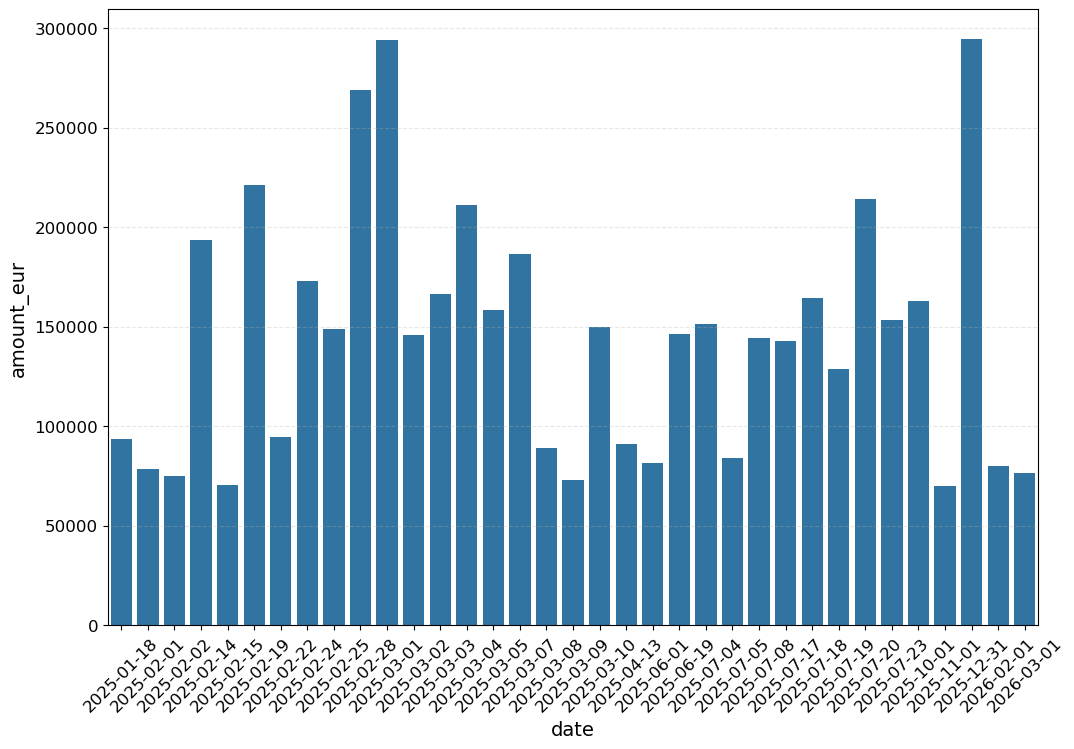

In [112]:
sns.barplot(x = anomalies.date, y = anomalies.amount_eur)
plt.xticks(rotation=45)
plt.show()

I found the highest density (and magnitude) of anomalies in the period from 2025-02-19 to 2025-02-28; let’s take a closer look at this period and try to understand what happened then.

In [113]:
start, end = '2025-02-19', '2025-02-28'

In [116]:
rush = dayly[(dayly.date >= start) & (dayly.date <= end)] 
rush

,date,amount_eur,weekday
49,2025-02-19,"221,308.62",Wednesday
50,2025-02-20,"116,136.31",Thursday
51,2025-02-21,"112,471.94",Friday
52,2025-02-22,"94,483.60",Saturday
53,2025-02-23,"66,376.59",Sunday
54,2025-02-24,"173,063.82",Monday
55,2025-02-25,"149,013.04",Tuesday
56,2025-02-26,"92,617.41",Wednesday
57,2025-02-27,"82,036.78",Thursday
58,2025-02-28,"269,009.70",Friday


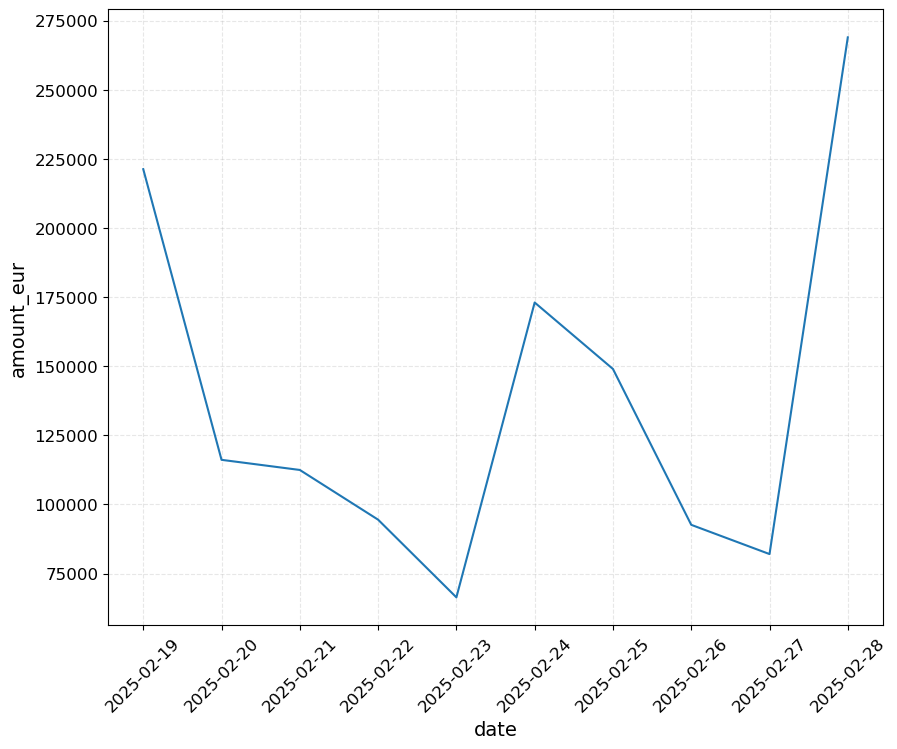

In [120]:
sns.lineplot(x = rush.date, y = rush.amount_eur)
plt.xticks(rotation=45)
plt.show()

In [123]:
df_news.head()

,date,daily_sources,daily_headers
0,2026-03-04,theguardian.com,['Ukraine war briefing: Merz tells Trump Ukraine must not give up more terri...
1,2026-03-03,kyivindependent.com | theguardian.com,"[""How will Trump's war against Iran impact Ukraine?"", 'What to do if you’re ..."
2,2026-03-02,kyivindependent.com | theguardian.com,['Any comparison of the US-Iran conflict to the Russia-Ukraine war is ignora...
3,2026-03-01,kyivindependent.com | theguardian.com,"[""'Ukrainians made it through,' Zelensky says on toughest winter of Russia's..."
4,2026-02-28,kyivindependent.com | theguardian.com,"[""Russia condemns US attack on its ally Iran as 'unprovoked act of aggressio..."


In [125]:
#connect events with news headers
news = rush.merge(df_news, how = 'left', on = 'date')
news

,date,amount_eur,weekday,daily_sources,daily_headers
0,2025-02-19,"221,308.62",Wednesday,theguardian.com,"['Trump blames Ukraine over war with Russia, saying it could have made a dea..."
1,2025-02-20,"116,136.31",Thursday,kyivindependent.com | theguardian.com,"[""European leaders back Zelensky after Trump's accusations""] | ['First Thing..."
2,2025-02-21,"112,471.94",Friday,theguardian.com,"['Ukraine war briefing: China lauds Trump’s Russia peace talks', 'Trump offi..."
3,2025-02-22,"94,483.60",Saturday,kyivindependent.com | theguardian.com,['Trump announces next round of Ukraine peace talks in Riyadh on Feb. 25'] |...
4,2025-02-23,"66,376.59",Sunday,theguardian.com,"['Starmer condemns Farage and Reform UK for ‘fawning over Putin’', 'Putin ha..."
5,2025-02-24,"173,063.82",Monday,kyivindependent.com | theguardian.com,"['Trudeau presses Trump on Ukraine peace deal ahead of Kyiv summit', 'Nordic..."
6,2025-02-25,"149,013.04",Tuesday,theguardian.com,"['Starmer must take baton from Macron in effort to sway Trump on Ukraine', '..."
7,2025-02-26,"92,617.41",Wednesday,kyivindependent.com | theguardian.com,['Media: Slovak National Party calls on Fico to apologize after Slovakia bac...
8,2025-02-27,"82,036.78",Thursday,theguardian.com,['Ukraine war briefing: Kyiv’s troops regain village near Pokrovsk where ISW...
9,2025-02-28,"269,009.70",Friday,kyivindependent.com | theguardian.com,['Kyiv Independent’s film about military medics will be screened in 6 more E...


In [131]:
news.loc[0, 'daily_headers']

"['Trump blames Ukraine over war with Russia, saying it could have made a deal', 'Why Europe’s defence spending may need a bold new approach', 'Kyiv’s White House wooing implodes as Zelenskyy tells the truth about Trump | Julian Borger', 'Trump trumps himself with latest delusional fantasies | John Crace', 'Britain and France working on plans for ‘reassurance force’ to protect Ukraine', 'Reagan-era Republicans aghast as Trump turns Russia policy on its head', 'Factchecking Donald Trump’s claims about the war in Ukraine', 'Ukrainians: share your views on the US-Russia peace talks about the war in Ukraine', 'Trump calls Zelenskyy a dictator amid fears of irreconcilable rift', 'First Thing: Trump blames Ukraine over war with Russia – ‘you never should have started it’', 'Boris Johnson fans offered £121 handshake and photo op', 'Even Trump can be cajoled into doing the right thing – you just have to know which buttons to press | Kenneth Roth', 'Ukraine war briefing: Drone squad ‘destroys r

In [132]:
news.loc[1, 'daily_headers']

'["European leaders back Zelensky after Trump\'s accusations"] | [\'First Thing: Trump calls Zelenskyy a dictator in unparalleled relations rift\', \'Nigel Farage dissents from Trump’s Zelenskyy ‘dictator’ claim\', \'The cameras weren’t rolling, so no one saw Lammy neglect to tackle Dictators United | John Crace\', \'Don’t be fooled by Putin’s ‘imperialism dressed up as realpolitik’, Lammy warns\', \'Trump’s savage attack on Zelenskyy shaped by pro-Russian coterie\', \'Stop criticising Trump and sign $500bn mineral deal, US official advises Kyiv\', \'People in the US: share your views on President Trump’s approach towards Russia and Ukraine\', \'Vance poses immigration as ‘greatest threat’ to US and Europe in CPAC speech\', \'Why hasn’t Ukraine held elections since the war began?\', \'US politics briefing: Trump rails against Zelenskyy and derails Senate Republicans’ budget proposal\', \'Thursday briefing: The real reasons that Volodymyr Zelenskyy can’t face a new election yet\', \'‘Wh

In [133]:
news.loc[2, 'daily_headers']

"['Ukraine war briefing: China lauds Trump’s Russia peace talks', 'Trump official says Zelenskyy will sign US minerals deal ‘in the very short term’', 'US envoy to Ukraine hails Zelenskyy as ‘embattled and courageous leader’', '‘Like a cruel auction’: what Ukrainians think of Trump’s peace talks with Putin', 'Trump is the world’s greatest showman – and the weakest strongman it has ever seen | Jonathan Freedland', 'No matter how distasteful we find Trump and Vance over Europe, they speak a blunt truth | Simon Jenkins', 'Trump is tearing up the transatlantic alliance. Can Starmer’s US visit change the weather?', 'What are we to make of Trump’s Ukraine policy? | Matt Duss']"

In [134]:
news.loc[3, 'daily_headers']

"['Trump announces next round of Ukraine peace talks in Riyadh on Feb. 25'] | ['Preparations under way for meeting between Trump and Putin, Russia says', 'Ukraine war briefing: Trump turnaround as he acknowledges Russia invaded Ukraine', 'Trump administration briefing: top immigration official removed and judge clears way for USAid firings', 'Culture wars: Trump’s takeover of arts is straight from the dictator playbook', 'Americans sharply divided over Trump’s embrace of Putin', 'Trump says he will end the war in Ukraine – but how, and who will benefit? Our panel responds | Olga Chyzh and others', 'Steve Witkoff: from property developer to global spotlight as Trump’s tough-talking troubleshooter', 'Keir Starmer lays down Ukraine peace demand ahead of Trump talks', '‘It’s blackmail’: Ukrainians react to Trump demand for $500bn share of minerals', 'What have three years of Putin’s war done to both nations’ economies?', 'Open-mouthed Farage struggles to find his voice as GB News is caught

Insights: Event-Driven Anomalies & Grassroots Mobilization
The Trigger (News Context): Event Study analysis links the historic donation peaks on February, 2025 to a sharp shift in US political rhetoric. Headlines from late February show intense pressure on Ukrainian leadership (e.g., forced peace talks, political blackmail, and the "$500bn mineral deal").

The Insight (Rally 'Round the Flag): The data reveals a direct inverse correlation: extreme external pressure for concessions drives immediate financial resistance from the public. Instead of apathy, political coercion triggered a massive grassroots mobilization.
Let's check another notable dates.

In [152]:
dayly[dayly['amount_eur'].isin(top_10_days)].sort_values('amount_eur', ascending = False)

,date,amount_eur,weekday
364,2025-12-31,"294,662.34",Wednesday
59,2025-03-01,"294,230.65",Saturday
58,2025-02-28,"269,009.70",Friday
49,2025-02-19,"221,308.62",Wednesday
200,2025-07-20,"214,226.61",Sunday
62,2025-03-04,"211,145.61",Tuesday
44,2025-02-14,"193,431.93",Friday
65,2025-03-07,"186,618.20",Friday
54,2025-02-24,"173,063.82",Monday
61,2025-03-03,"166,484.98",Monday
